# 01. Imágenes como matrices

**Objetivo:** comprender cómo una imagen digital se representa con números y aprender a inspeccionar su estructura antes de procesarla.

In [1]:
import numpy as np
import cv2

from filtrado_digital.io import cargar_imagen, a_grises, ruta_imagen_ejemplo
from filtrado_digital.visualizacion import mostrar_imagen, comparar

## 1. Píxeles, intensidades y matrices

Una imagen digital está formada por **píxeles**. Un píxel es la unidad más pequeña de una imagen digital y almacena información de intensidad o color.

En una imagen en escala de grises podemos representar cada píxel con un número entre `0` y `255`:

- `0` representa negro;
- `255` representa blanco;
- los valores intermedios representan distintos tonos de gris.

Al organizar esos valores en filas y columnas obtenemos una **matriz**. NumPy representa esa matriz mediante un arreglo (`numpy.ndarray`).

[[  0   0   0   0   0   0   0]
 [  0  80  80  80  80  80   0]
 [  0  80 255 255 255  80   0]
 [  0  80  80  80  80  80   0]
 [  0   0   0   0   0   0   0]]


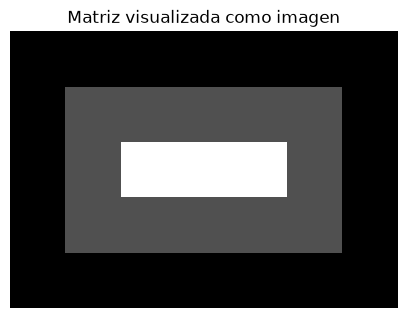

In [2]:
# Una pequeña imagen de 5 filas y 7 columnas.
imagen_pequena = np.array([
    [0,   0,   0,   0,   0,   0,   0],
    [0,  80,  80,  80,  80,  80,   0],
    [0,  80, 255, 255, 255,  80,   0],
    [0,  80,  80,  80,  80,  80,   0],
    [0,   0,   0,   0,   0,   0,   0],
], dtype=np.uint8)

print(imagen_pequena)
mostrar_imagen(imagen_pequena, "Matriz visualizada como imagen")

## 2. ¿Qué es `shape`?

`shape` es un atributo de los arreglos de NumPy que indica **cuántos elementos existen en cada dimensión**.

Para una imagen en escala de grises suele tener la forma:

```text
(alto, ancho)
```

Por ejemplo, `shape = (512, 768)` significa 512 filas (alto) y 768 columnas (ancho).

Una imagen RGB suele tener:

```text
(alto, ancho, canales)
```

Por ejemplo, `(512, 768, 3)` contiene tres canales de color.

> `shape` describe la estructura del arreglo; no indica cuánto pesa el archivo en KB o MB.

### ¿Qué es `dtype`?

`dtype` significa **data type** o tipo de dato. Indica cómo se almacenan los valores del arreglo. En imágenes de 8 bits es común `uint8`, un entero sin signo cuyo rango es de `0` a `255`.

In [3]:
print("shape:", imagen_pequena.shape)
print("dtype:", imagen_pequena.dtype)
print("mínimo:", imagen_pequena.min())
print("máximo:", imagen_pequena.max())

shape: (5, 7)
dtype: uint8
mínimo: 0
máximo: 255


## 3. Fotografías RGB y escala de grises

Una fotografía RGB guarda tres componentes por píxel: **rojo (R), verde (G) y azul (B)**. Una imagen en escala de grises guarda una sola intensidad por píxel.

### RGB vs BGR en OpenCV

Muchas bibliotecas muestran imágenes a color como RGB. Sin embargo, `cv2.imread()` de OpenCV carga por defecto los canales en orden **BGR** (azul, verde, rojo). Si una matriz BGR se muestra como si fuera RGB, los colores se ven incorrectos.

Por eso conviene convertir explícitamente BGR → RGB antes de visualizar con Matplotlib. La función `cargar_imagen()` del proyecto ya realiza esa conversión.

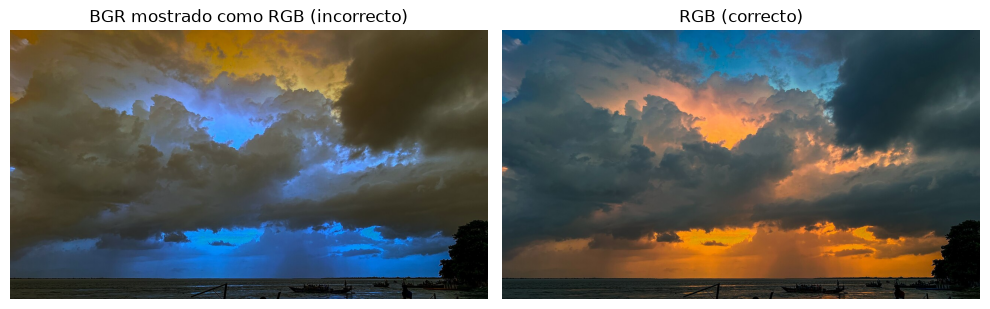

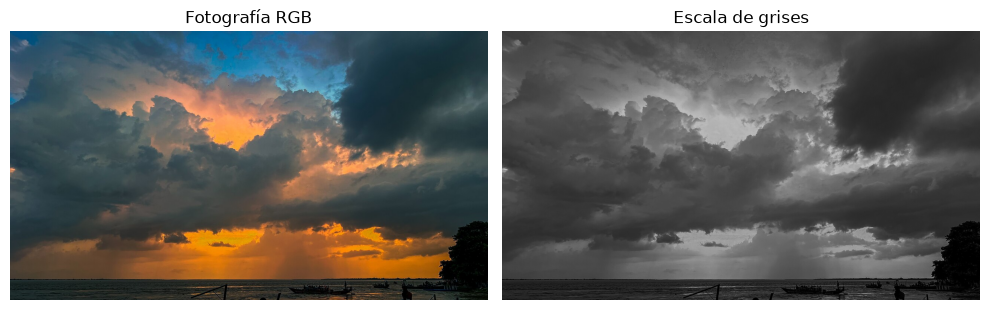

RGB shape: (720, 1280, 3)
Grises shape: (720, 1280)
dtype: uint8


In [4]:
ruta = ruta_imagen_ejemplo()

# Demostración de la diferencia BGR/RGB.
foto_bgr = cv2.imread(str(ruta))
foto_rgb = cv2.cvtColor(foto_bgr, cv2.COLOR_BGR2RGB)
comparar([foto_bgr, foto_rgb], ["BGR mostrado como RGB (incorrecto)", "RGB (correcto)"])

# La función del proyecto devuelve directamente RGB.
foto = cargar_imagen(ruta)
foto_gris = a_grises(foto)
comparar([foto, foto_gris], ["Fotografía RGB", "Escala de grises"])

print("RGB shape:", foto.shape)
print("Grises shape:", foto_gris.shape)
print("dtype:", foto_gris.dtype)

## 4. Construcción manual de una imagen

También podemos crear imágenes directamente como matrices. En el siguiente ejemplo se construye un círculo blanco sobre fondo negro evaluando, píxel por píxel, si cada coordenada pertenece al círculo.

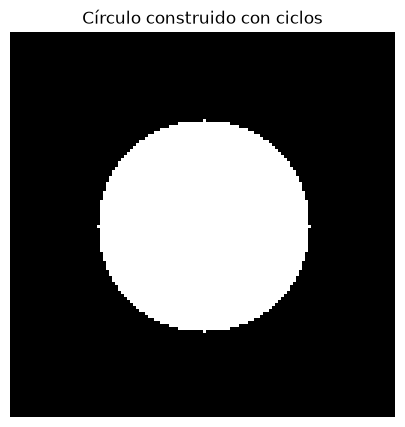

In [5]:
tamano = 128
radio = 35
centro = tamano // 2
imagen_manual = np.zeros((tamano, tamano), dtype=np.uint8)

for fila in range(tamano):
    for columna in range(tamano):
        distancia2 = (fila - centro)**2 + (columna - centro)**2
        if distancia2 <= radio**2:
            imagen_manual[fila, columna] = 255

mostrar_imagen(imagen_manual, "Círculo construido con ciclos")

## Conclusiones

- Una imagen digital puede representarse como un arreglo de NumPy.
- `shape` indica las dimensiones del arreglo y `dtype` el tipo de dato.
- Una imagen RGB contiene tres canales; una imagen en grises contiene una intensidad por píxel.
- OpenCV carga imágenes a color en BGR, por lo que suele ser necesario convertirlas a RGB para visualizarlas correctamente.